In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

BASE_DIR=Path(os.getcwd())
PROCESSED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"processed"
FILTERED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"filtered"
OUTPUTS_DIR=BASE_DIR/"brd4_pipeline"/"outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

df=pd.read_csv(FILTERED_DIR/"brd4_druglike.csv")

morgan_fps=np.load(PROCESSED_DIR/"brd4_morgan_fp.npy")

print(f"[INFO] Molecules loaded : {len(df):,}")
print(f"[INFP] Fingerprint matrix : {morgan_fps.shape}")

X=morgan_fps
y=df['pIC50'].values

print(f"\n[INFO] X Shape : {X.shape}")
print(f"[INFO] y shape : {y.shape}")
print(f"[INFO] y range : {y.min():.2f} - {y.max():.2f}")

[INFO] Molecules loaded : 2,210
[INFP] Fingerprint matrix : (2210, 2048)

[INFO] X Shape : (2210, 2048)
[INFO] y shape : (2210,)
[INFO] y range : 3.59 - 10.92


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape[0]:,} molecules")
print(f"Test set : {X_test.shape[0]:,} molecules")
print(f"Train pIC50 : {y_train.mean():.2f} +- {y_train.std():.2f}")
print(f"Test pIC50 : {y_test.mean():.2f} +- {y_test.std():.2f}")
print()
print("Train and test pIC50 means should be similar.")
print("If very different , the split is unbalanced.")

Training set : 1,768 molecules
Test set : 442 molecules
Train pIC50 : 7.18 +- 1.24
Test pIC50 : 7.24 +- 1.21

Train and test pIC50 means should be similar.
If very different , the split is unbalanced.


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import warnings

In [4]:
warnings.filterwarnings('ignore')

In [7]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    print(f"\n--- {name} ---")

    cv_scores = cross_val_score(model, X_tr, y_tr,
                                 cv=5, scoring='r2')
    print(f"  CV R² scores : {cv_scores.round(3)}")
    print(f"  CV R² mean   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    test_r2   = r2_score(y_te, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    print(f"  Test R²      : {test_r2:.3f}")
    print(f"  Test RMSE    : {test_rmse:.3f}")

    train_r2 = r2_score(y_tr, model.predict(X_tr))
    gap      = train_r2 - test_r2
    print(f"  Train R²     : {train_r2:.3f}")
    print(f"  Overfit gap  : {gap:.3f}  ", end="")
    if gap > 0.2:
        print("WARNING: possible overfitting")
    else:
        print("acceptable")

    return {
        'name'      : name,
        'model'     : model,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std' : cv_scores.std(),
        'test_r2'   : test_r2,
        'test_rmse' : test_rmse,
        'train_r2'  : train_r2,
        'y_pred'    : y_pred
    }


rf_model = RandomForestRegressor(
    n_estimators=100,   
    random_state=42,
    n_jobs=-1
)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

print("[INFO] Training and evaluating all models...")
print("This may take 3-5 minutes.\n")

results = []

results.append(evaluate_model(
    "Random Forest", rf_model,
    X_train, y_train, X_test, y_test
))

results.append(evaluate_model(
    "XGBoost", xgb_model,
    X_train, y_train, X_test, y_test
))

results.append(evaluate_model(
    "SVM (RBF kernel)", svm_model,
    X_train_scaled, y_train,
    X_test_scaled, y_test
))

[INFO] Training and evaluating all models...
This may take 3-5 minutes.


--- Random Forest ---
  CV R² scores : [0.666 0.658 0.719 0.728 0.658]
  CV R² mean   : 0.686 ± 0.031
  Test R²      : 0.714
  Test RMSE    : 0.650
  Train R²     : 0.948
  Overfit gap  : 0.234  WARNING: possible overfitting

--- XGBoost ---
  CV R² scores : [0.685 0.678 0.716 0.722 0.656]
  CV R² mean   : 0.691 ± 0.024
  Test R²      : 0.706
  Test RMSE    : 0.658
  Train R²     : 0.869
  Overfit gap  : 0.162  acceptable

--- SVM (RBF kernel) ---
  CV R² scores : [0.554 0.62  0.599 0.64  0.594]
  CV R² mean   : 0.601 ± 0.029
  Test R²      : 0.655
  Test RMSE    : 0.713
  Train R²     : 0.886
  Overfit gap  : 0.230  WARNING: possible overfitting


In [8]:
from sklearn.model_selection import GridSearchCV

In [10]:
print(f"[INFO] Running GridSearchCV for Random Forest...")
print("[INFO] Thos will take 5-10 min.\n")

rf_param_grid={
    'n_estimators' : [100,200],
    'max_depth': [None, 10, 20],
    'min_samples_split' : [2,5]}

rf_grid =GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1)

rf_grid.fit(X_train, y_train)

print(f"\nBest RF parameters : {rf_grid.best_params_}")
print(f" Best RF CV R2 : {rf_grid.best_score_:.3f}")

y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
print(f"Tuned RF Test R2 : {rf_tuned_r2:.3f}")
print(f" Tuned RF Test RMSE : {rf_tuned_rmse:.3f}")

print("\n[INFO] Running GridSearchCV for XGBosst...")

xgb_param_grid={
    'n_estimators':[100,200],
    'learning_rate':[0.05, 0.1],
    'max_depth':[3,6]}

xgb_grid=GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1)

xgb_grid.fit(X_train, y_train)

print(f"\nBest XGB Parameters : {xgb_grid.best_params_}")
print(f"Best XGB CV R2 : {xgb_grid.best_score_:.3f}")

y_pred_xgb_tuned=xgb_grid.best_estimator_.predict(X_test)
xgb_tuned_r2=r2_score(y_test, y_pred_xgb_tuned)
xgb_tuned_rmse= np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
print(f"Tuned XGB Test R2 : {xgb_tuned_r2:.3f}")
print(f"Tuned XGB Test RMSE : {xgb_tuned_rmse:.3f}")

[INFO] Running GridSearchCV for Random Forest...
[INFO] Thos will take 5-10 min.

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best RF parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
 Best RF CV R2 : 0.687
Tuned RF Test R2 : 0.715
 Tuned RF Test RMSE : 0.648

[INFO] Running GridSearchCV for XGBosst...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best XGB Parameters : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best XGB CV R2 : 0.699
Tuned XGB Test R2 : 0.710
Tuned XGB Test RMSE : 0.654


In [11]:
import matplotlib.pyplot as plt

comparison=pd.DataFrame([
    {'Model':'Random Forest (default)',
     'CV R2' : results[0]['cv_r2_mean'],
     'Test R2': results[0]['test_r2'],
     'Test RMSE':results[0]['test_rmse']},

    {'Model': 'Random Forest (tuned)',
     'CV R2' : rf_grid.best_score_,
     'Test R2': rf_tuned_r2,
     'Test RMSE':rf_tuned_rmse},

    {'Model':'XGBoost (default)',
     'CV R2' : results[1]['cv_r2_mean'],
     'Test R2':results[1]['test_r2'],
     'Test RMSE':results[1]['test_rmse']},

    {'Model' : 'XGBoost (tuned)',
     'CV R2':xgb_grid.best_score_,
     'Test R2':xgb_tuned_r2,
     'Test RMSE':xgb_tuned_rmse},

    {'Model':'SVM (default)',
     'CV R2':results[2]['cv_r2_mean'],
     'Test R2':results[2]['test_r2'],
     'Test RMSE':results[2]['test_rmse']}])

print("="*65)
print("MODEL COMPARISON TABLE")
print("="*65)
print(comparison.to_string(index=False))
print("="*65)

best_idx=comparison['Test R2'].idxmax()
best_name=comparison.loc[best_idx, 'Model']
best_r2=comparison.loc[best_idx, 'Test R2']
best_rmse=comparison.loc[best_idx, 'Test RMSE']

print(f"\nBest Model : {best_name}")
print(f"Test R2 :{best_r2:.3f}")
print(f"Test RMSE : {best_rmse:.3f}")

if 'XGBoost (tuned)' in best_name:
    best_model=xgb_grid.best_estimator_
    best_X_test=X_test
elif 'XGBoost' in best_name:
    best_model=results[1]['model']
    best_X_test=X_test
elif 'Random Forest (tuned)' in best_name:
    best_model=rf_grid.best_estimator_
    best_X_test=X_test
elif 'Random Forest' in best_name:
    best_model=results[0]['model']
    best_X_test=X_test
else:
    best_model=results[2]['model']
    best_X_test=X_test_scaled

MODEL COMPARISON TABLE
                  Model    CV R2  Test R2  Test RMSE
Random Forest (default) 0.686064 0.713571   0.649834
  Random Forest (tuned) 0.686934 0.714831   0.648404
      XGBoost (default) 0.691370 0.706269   0.658066
        XGBoost (tuned) 0.699149 0.710270   0.653569
          SVM (default) 0.601198 0.655122   0.713061

Best Model : Random Forest (tuned)
Test R2 :0.715
Test RMSE : 0.648


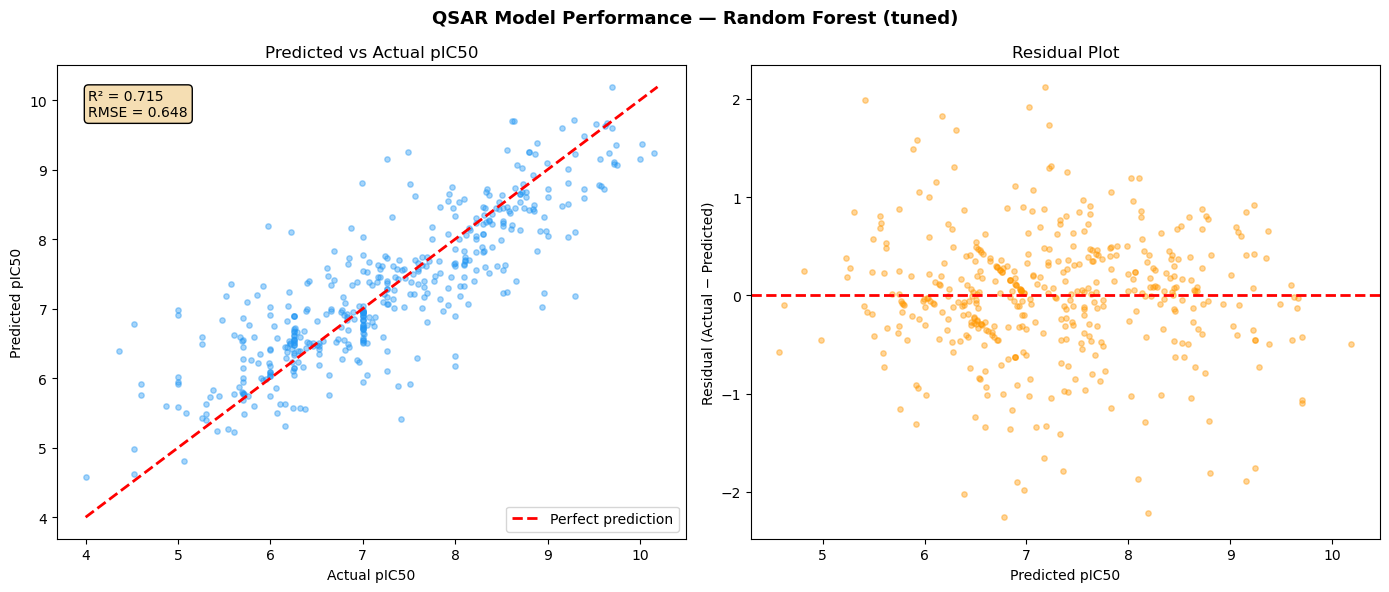

[SAVED] Model performance plot saved.


In [12]:
y_pred_best = best_model.predict(best_X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'QSAR Model Performance — {best_name}',
             fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_best, alpha=0.4,
                color='#2196F3', s=15)

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect prediction')

axes[0].set_xlabel('Actual pIC50')
axes[0].set_ylabel('Predicted pIC50')
axes[0].set_title('Predicted vs Actual pIC50')
axes[0].legend()
axes[0].text(0.05, 0.95,
             f'R² = {best_r2:.3f}\nRMSE = {best_rmse:.3f}',
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat'))

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals,
                alpha=0.4, color='#FF9800', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted pIC50')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module05_model_performance.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Model performance plot saved.")

In [13]:
import pickle

model_file = PROCESSED_DIR / "brd4_best_model.pkl"
with open(model_file, 'wb') as f:
    pickle.dump(best_model, f)
print(f"[SAVED] Best model: {model_file}")

if 'SVM' in best_name:
    scaler_file = PROCESSED_DIR / "brd4_scaler.pkl"
    with open(scaler_file, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"[SAVED] Scaler: {scaler_file}")
model_meta = {
    'best_model_name' : best_name,
    'test_r2'         : round(best_r2, 4),
    'test_rmse'       : round(best_rmse, 4),
    'requires_scaling': 'SVM' in best_name
}
import json
meta_file = PROCESSED_DIR / "brd4_model_meta.json"
with open(meta_file, 'w') as f:
    json.dump(model_meta, f, indent=2)

print("=" * 55)
print("  MODULE 5 — PIPELINE AUDIT REPORT")
print("  Target: BRD4 (CHEMBL4523)")
print("=" * 55)
print(f"  Training molecules  : {X_train.shape[0]:,}")
print(f"  Test molecules      : {X_test.shape[0]:,}")
print()
print(f"  Model Comparison:")
print(comparison.to_string(index=False))
print()
print(f"  Best model          : {best_name}")
print(f"  Test R²             : {best_r2:.3f}")
print(f"  Test RMSE           : {best_rmse:.3f}")
print()
print("  Files saved:")
print("  processed/  brd4_best_model.pkl")
print("  processed/  brd4_model_meta.json")
print("  outputs/    module05_model_performance.png")
print("=" * 55)
print("  Module 5 complete.")
print("=" * 55)

[SAVED] Best model: C:\Users\raksh\brd4_pipeline\data\processed\brd4_best_model.pkl
  MODULE 5 — PIPELINE AUDIT REPORT
  Target: BRD4 (CHEMBL4523)
  Training molecules  : 1,768
  Test molecules      : 442

  Model Comparison:
                  Model    CV R2  Test R2  Test RMSE
Random Forest (default) 0.686064 0.713571   0.649834
  Random Forest (tuned) 0.686934 0.714831   0.648404
      XGBoost (default) 0.691370 0.706269   0.658066
        XGBoost (tuned) 0.699149 0.710270   0.653569
          SVM (default) 0.601198 0.655122   0.713061

  Best model          : Random Forest (tuned)
  Test R²             : 0.715
  Test RMSE           : 0.648

  Files saved:
  processed/  brd4_best_model.pkl
  processed/  brd4_model_meta.json
  outputs/    module05_model_performance.png
  Module 5 complete.
